This script prepares the FD001 training data using a data-driven approach.

It performs the following steps:
1.  Loads the train_FD001.txt dataset.
2.  Calculates the Remaining Useful Life (RUL) for each time step.
3.  Removes features with constant values (zero variance).
4.  Feature Summary Statistics
5.  Analyze correlations and remove redundant features
6.  Standardizes the selected features using StandardScaler.
7.  Saves the final, prepared training data to the Kaggle output directory.

## **STEP 1: INITIAL SETUP AND DATA LOADING**

This step loads the NASA C-MAPSS FD001 dataset, assigns appropriate column names,
and verifies its structure before preprocessing.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import os
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")


DATASET_DIR = "/kaggle/input/nasa-cmaps/CMaps/" 
OUTPUT_DIR = "/kaggle/working/" 

# Create the output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define file path for the FD001 training dataset
train_file = os.path.join(DATASET_DIR, 'train_FD001.txt')

# Define the column names for the C-MAPSS data
col_names = ['unit_nr', 'cycle', 'setting1', 'setting2', 'setting3'] + [f'sensor{i}' for i in range(1, 22)]

# --- Load the Training Data ---
df_train_raw = pd.read_csv(train_file, sep='\s+', header=None, names=col_names)
print(f"Raw data shape: {df_train_raw.shape}")

Raw data shape: (20631, 26)


## **STEP 2: CALCULATE REMAINING USEFUL LIFE (RUL)**

Each engine operates until failure, so the RUL at each cycle is defined as the
difference between the last observed cycle for that engine and the current cycle.
This transforms the dataset into a supervised regression format.

In [2]:
# Group by the engine number ('unit_nr') and find the maximum cycle value.
max_cycles = df_train_raw.groupby('unit_nr')['cycle'].max().reset_index()
max_cycles.columns = ['unit_nr', 'max_cycle']

# Merge this 'max_cycle' information back into the original dataframe.
df_train_processed = df_train_raw.merge(max_cycles, on='unit_nr', how='left')

# Calculate RUL = (Last Cycle) - (Current Cycle)
df_train_processed['RUL'] = df_train_processed['max_cycle'] - df_train_processed['cycle']

# Drop the temporary 'max_cycle' column.
df_train_processed = df_train_processed.drop('max_cycle', axis=1)
print("RUL calculation complete.")

RUL calculation complete.


## **STEP 3: REMOVE CONSTANT AND QUASI-CONSTANT FEATURES**
- Calculate the standard deviation for each column.
- Using standard deviation is often more intuitive than variance for setting a threshold.
- Features with a standard deviation of 0 are strictly constant.
- Features with a very low standard deviation are quasi-constant and provide little to no information.

In [3]:
# 1. Calculate standard deviation for each column
std_dev = df_train_processed.std()

# 2. Sort std values in ascending order for inspection
std_dev_sorted = std_dev.sort_values(ascending=True)

print("\n Standard deviation of all features (sorted ascending):")
for col, val in std_dev_sorted.items():
    print(f"{col:15} {val:.10f}")

# 3. Identify strictly constant features (std = 0)
constant_columns = std_dev[std_dev == 0].index.tolist()

# 4. Identify quasi-constant features (0 < std < threshold)
quasi_constant_columns = std_dev[(std_dev > 0) & (std_dev < 1e-2)].index.tolist()

# 5. Combine all columns to be removed
cols_to_remove = constant_columns + quasi_constant_columns

# 6. Log findings
if constant_columns:
    print(f"\nFound {len(constant_columns)} strictly constant columns to remove: {constant_columns}")
else:
    print("\nNo strictly constant columns found.")

if quasi_constant_columns:
    print(f"Found {len(quasi_constant_columns)} quasi-constant columns to remove (std < 1e-2): {quasi_constant_columns}")
else:
    print("No quasi-constant columns found.")

# 7. Drop the identified columns
if cols_to_remove:
    df_train_processed.drop(columns=cols_to_remove, inplace=True)
    print(f"\nDropped a total of {len(cols_to_remove)} uninformative columns. New shape: {df_train_processed.shape}")
else:
    print("\nNo constant or quasi-constant columns to remove.")

# 8. Display remaining columns for verification
print("\nRemaining columns after removal:")
print(df_train_processed.columns.tolist())



 Standard deviation of all features (sorted ascending):
sensor19        0.0000000000
setting3        0.0000000000
sensor18        0.0000000000
sensor16        0.0000000000
sensor10        0.0000000000
sensor5         0.0000000000
sensor1         0.0000000001
setting2        0.0002930621
sensor6         0.0013889849
setting1        0.0021873134
sensor15        0.0375050380
sensor8         0.0709854789
sensor13        0.0719189157
sensor21        0.1082508747
sensor20        0.1807464279
sensor11        0.2670873986
sensor2         0.5000532701
sensor12        0.7375533922
sensor7         0.8850922577
sensor17        1.5487630246
sensor3         6.1311495197
sensor4         9.0006047805
sensor14        19.0761759760
sensor9         22.0828795251
unit_nr         29.2276329088
RUL             68.8809901772
cycle           68.8809901772

Found 3 strictly constant columns to remove: ['setting3', 'sensor18', 'sensor19']
Found 7 quasi-constant columns to remove (std < 1e-2): ['setting1', 'set

## **STEP 4: Feature Summary Statistics**

this step helps verify that:

The retained sensors still carry variability (useful information for modeling).

No remaining sensor is constant or near-constant.

Feature scales and magnitudes are clearly understood before standardization


In [4]:
# Define the sensor feature columns (excluding identifiers and target)
sensor_features = [col for col in df_train_processed.columns 
                     if col not in ['unit_nr', 'cycle', 'RUL']]

# Display basic descriptive statistics for the remaining sensor features
df_train_processed[sensor_features].describe().T[['mean', 'std', 'min', 'max']]


,mean,std,min,max
sensor2,642.680934,0.500053,641.2100,644.5300
sensor3,1590.523119,6.131150,1571.0400,1616.9100
sensor4,1408.933782,9.000605,1382.2500,1441.4900
sensor7,553.367711,0.885092,549.8500,556.0600
sensor8,2388.096652,0.070985,2387.9000,2388.5600
sensor9,9065.242941,22.082880,9021.7300,9244.5900
sensor11,47.541168,0.267087,46.8500,48.5300
sensor12,521.413470,0.737553,518.6900,523.3800
sensor13,2388.096152,0.071919,2387.8800,2388.5600
sensor14,8143.752722,19.076176,8099.9400,8293.7200


After removing uninformative features, 14 sensor variables remain.
Their standard deviations indicate sufficient variability for modeling, with sensors 3, 4, 9, and 14 showing the highest dynamic range. These are expected to play key roles in predicting Remaining Useful Life (RUL).

Next, we analyze correlations among these remaining features to identify redundant signals that may lead to multicollinearity during modeling.

## **STEP 5: ANALYZE CORRELATIONS AND REMOVE REDUNDANT FEATURES**

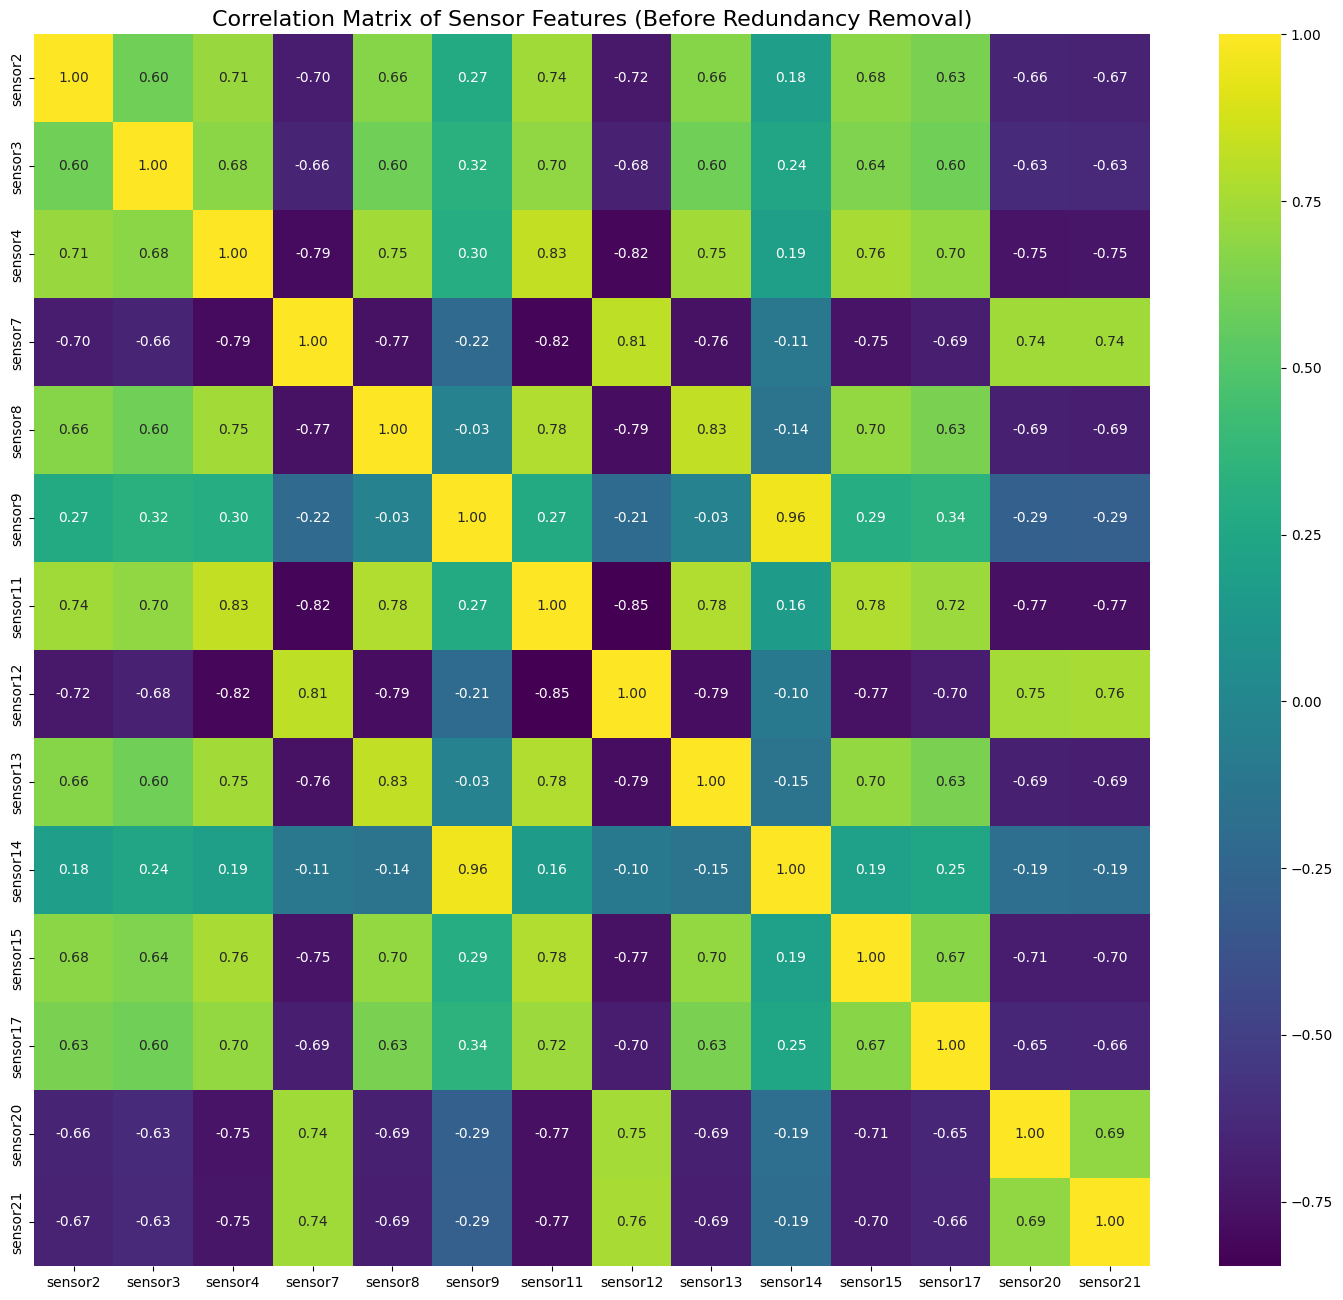

Dropping 'sensor11' — correlated with 'sensor4' (r = 0.83)
Dropping 'sensor11' — correlated with 'sensor7' (r = -0.82)
Dropping 'sensor12' — correlated with 'sensor4' (r = -0.82)
Dropping 'sensor12' — correlated with 'sensor7' (r = 0.81)
Dropping 'sensor12' — correlated with 'sensor11' (r = -0.85)
Dropping 'sensor13' — correlated with 'sensor8' (r = 0.83)
Dropping 'sensor14' — correlated with 'sensor9' (r = 0.96)

Found 4 highly correlated columns to remove (threshold > 0.8): ['sensor11', 'sensor12', 'sensor13', 'sensor14']
Dropped redundant columns. New shape: (20631, 13)


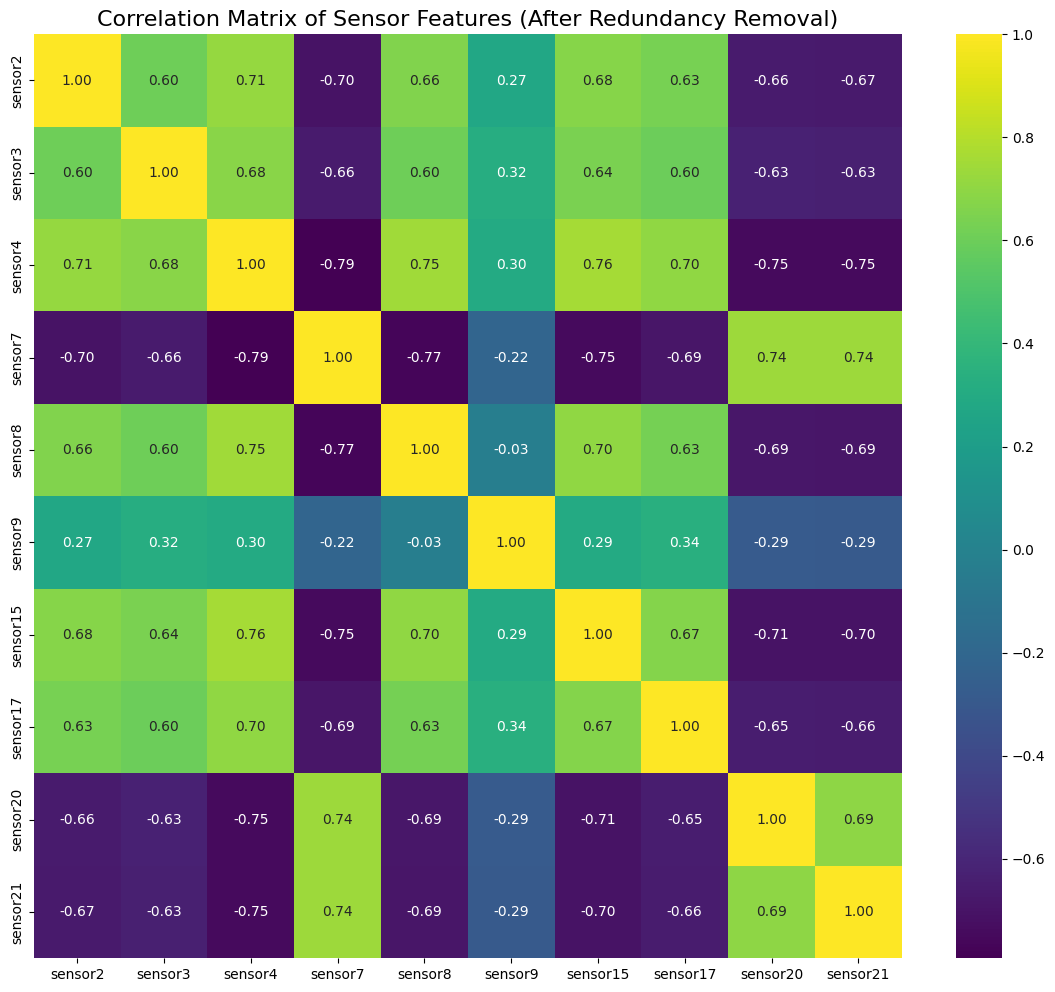

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only sensor columns
sensor_cols = [col for col in df_train_processed.columns if 'sensor' in col]

# Compute correlation matrix
correlation_matrix = df_train_processed[sensor_cols].corr()

# Plot correlation matrix before removal
plt.figure(figsize=(18, 16))
sns.heatmap(
    correlation_matrix, 
    annot=True,          
    fmt=".2f",          
    cmap='viridis',      
    linewidths=0        
)
plt.title("Correlation Matrix of Sensor Features (Before Redundancy Removal)", fontsize=16)
plt.show()

# Set correlation threshold
correlation_threshold = 0.80
cols_to_drop = set()

# Check the upper triangle of the matrix
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > correlation_threshold:
            colname = correlation_matrix.columns[i]
            print(f"Dropping '{colname}' — correlated with '{correlation_matrix.columns[j]}' (r = {correlation_matrix.iloc[i, j]:.2f})")
            cols_to_drop.add(colname)

# Drop redundant columns
if cols_to_drop:
    print(f"\nFound {len(cols_to_drop)} highly correlated columns to remove (threshold > {correlation_threshold}): {sorted(cols_to_drop)}")
    df_train_processed.drop(columns=list(cols_to_drop), inplace=True)
    print(f"Dropped redundant columns. New shape: {df_train_processed.shape}")
else:
    print(f"\nNo columns found with correlation above the threshold of {correlation_threshold}.")

# Plot correlation matrix after removal
new_sensor_cols = [col for col in df_train_processed.columns if 'sensor' in col]
new_correlation_matrix = df_train_processed[new_sensor_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    new_correlation_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='viridis', 
    linewidths=0
)
plt.title("Correlation Matrix of Sensor Features (After Redundancy Removal)", fontsize=16)
plt.show()


## **Step 6: Standardize Selected Features**

* Only sensor features are standardized (excluding `unit_nr`, `cycle`, and `RUL`).
* Each selected feature is rescaled to have mean = 0 and standard deviation = 1 using `StandardScaler`.
* This transformation ensures equal weight for all features in model training.


In [6]:
from sklearn.preprocessing import StandardScaler

# 1. Identify columns to scale
features_to_scale = [col for col in df_train_processed.columns 
                     if col not in ['unit_nr', 'cycle', 'RUL']]

# 2. Initialize scaler
scaler = StandardScaler()

# 3. Fit and transform the selected features
df_train_processed[features_to_scale] = scaler.fit_transform(df_train_processed[features_to_scale])

print(f" Standardization complete. Scaled {len(features_to_scale)} features:")


 Standardization complete. Scaled 10 features:


## **Step 7: Save the Prepared Dataset**

* The fully processed FD001 dataset (with scaled features and RUL) is saved as a CSV file.
* This final file is ready for training, validation, or further analysis.

In [7]:
# Define output file path
output_file = os.path.join(OUTPUT_DIR, "train_FD001_prepared.csv")

# Save to CSV
df_train_processed.to_csv(output_file, index=False)

print(f" Prepared FD001 dataset saved to: {output_file}")
print(f"Final shape: {df_train_processed.shape}")

 Prepared FD001 dataset saved to: /kaggle/working/train_FD001_prepared.csv
Final shape: (20631, 13)
